# Atividade — Meios de Transporte






In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



arquivo = 'Tabela_13_Meio_de_transporte.xlsx'

sns.set_theme(style='whitegrid')

print('Bibliotecas importadas!')


Bibliotecas importadas!


## Parte 1

Ler a aba **Exemplo gráfico Brasil** e fazer os 3 pie charts.

As porcentagens serão mostradas com **3 casas decimais**.


In [2]:


df = pd.read_excel(arquivo, sheet_name='Exemplo gráfico Brasil', header=None)


df = df.iloc[2:].copy()
df.columns = ['Meio de Transporte', 'Branca', 'Preta ou Parda', 'Indígena']

for coluna in ['Branca', 'Preta ou Parda', 'Indígena']:
    df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

df = df.dropna(subset=['Meio de Transporte'])

display(df)


,Meio de Transporte,Branca,Preta ou Parda,Indígena
2,A pé,19.4,24.8,37.5
3,Bicicleta,3.2,5.2,5.9
4,Motocicleta ou Mototaxi,9.9,14.2,15.4
5,"Automóvel, taxi ou assemelhados",41.8,20.6,15.2
6,Transporte coletivo,25.2,34.6,22.4
7,Outros,0.5,0.6,3.6


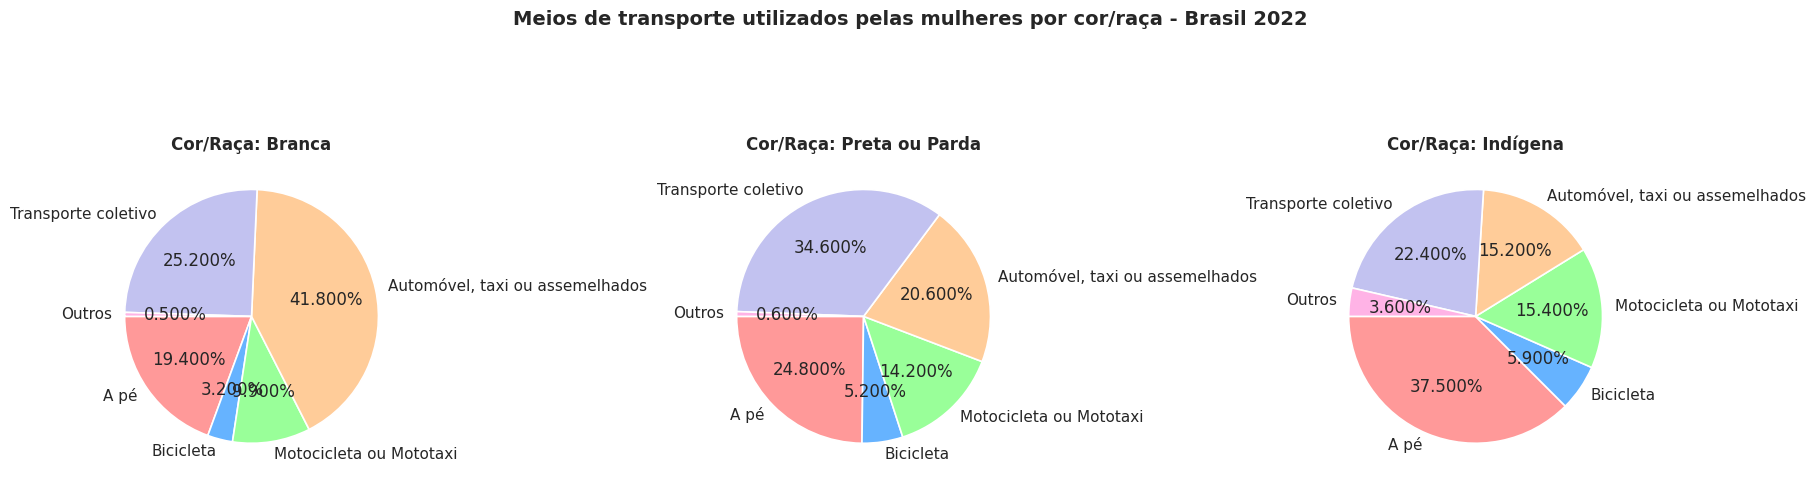

In [3]:


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

cores = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
grupos = ['Branca', 'Preta ou Parda', 'Indígena']

for i, col in enumerate(grupos):
    axes[i].pie(
        df[col],
        labels=df['Meio de Transporte'],
        autopct='%1.3f%%',
        startangle=180,
        colors=cores,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
    )
    axes[i].set_title(f'Cor/Raça: {col}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Meios de transporte utilizados pelas mulheres por cor/raça - Brasil 2022',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('grafico_transporte.png', dpi=300, bbox_inches='tight')
plt.show()


In [4]:


for _, linha in df.iterrows():
    modo = linha['Meio de Transporte']
    print(f'--- {modo} ---')
    print(f"Brancas - Pretas/Pardas: {linha['Branca'] - linha['Preta ou Parda']:.3f} pontos percentuais")
    print(f"Brancas - Indígenas: {linha['Branca'] - linha['Indígena']:.3f} pontos percentuais")
    print(f"Pretas/Pardas - Indígenas: {linha['Preta ou Parda'] - linha['Indígena']:.3f} pontos percentuais")


--- A pé ---
Brancas - Pretas/Pardas: -5.400 pontos percentuais
Brancas - Indígenas: -18.100 pontos percentuais
Pretas/Pardas - Indígenas: -12.700 pontos percentuais
--- Bicicleta ---
Brancas - Pretas/Pardas: -2.000 pontos percentuais
Brancas - Indígenas: -2.700 pontos percentuais
Pretas/Pardas - Indígenas: -0.700 pontos percentuais
--- Motocicleta ou Mototaxi ---
Brancas - Pretas/Pardas: -4.300 pontos percentuais
Brancas - Indígenas: -5.500 pontos percentuais
Pretas/Pardas - Indígenas: -1.200 pontos percentuais
--- Automóvel, taxi ou assemelhados ---
Brancas - Pretas/Pardas: 21.200 pontos percentuais
Brancas - Indígenas: 26.600 pontos percentuais
Pretas/Pardas - Indígenas: 5.400 pontos percentuais
--- Transporte coletivo ---
Brancas - Pretas/Pardas: -9.400 pontos percentuais
Brancas - Indígenas: 2.800 pontos percentuais
Pretas/Pardas - Indígenas: 12.200 pontos percentuais
--- Outros ---
Brancas - Pretas/Pardas: -0.100 pontos percentuais
Brancas - Indígenas: -3.100 pontos percentuais
P

In [5]:


bruto = pd.read_excel(arquivo, sheet_name='BR GR UF MU', header=None)

print('Linhas e colunas:', bruto.shape)
display(bruto.iloc[:6, :8])


Linhas e colunas: (5606, 19)


,0,1,2,3,4,5,6,7
0,Tabela 13 - Distribuição percentual das mulher...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"Brasil, Grande Região, Unidade da Federação e ...",Branca,NaN,NaN,NaN,NaN,NaN,Preta ou Parda
2,NaN,A pé,Bicicleta,Motocicleta ou Mototaxi,"Automóvel, taxi ou assemelhados",Transporte coletivo,Outros,A pé
3,Brasil,19.4,3.2,9.9,41.8,25.2,0.5,24.8
4,Norte,15.2,5.9,24.5,35.1,17.9,1.3,21.3
5,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5,31.7


In [6]:


modos = [
    'A pé',
    'Bicicleta',
    'Motocicleta ou Mototaxi',
    'Automóvel, taxi ou assemelhados',
    'Transporte coletivo',
    'Outros'
]

racas = ['Branca', 'Preta ou Parda', 'Indígena']

dados = bruto.iloc[3:].copy()
dados = dados.rename(columns={0: 'Local'})


novas_colunas = ['Local']

for raca in racas:
    for modo in modos:
        novas_colunas.append(f'{raca} - {modo}')

dados = dados.iloc[:, :19]
dados.columns = novas_colunas

for coluna in novas_colunas[1:]:
    dados[coluna] = pd.to_numeric(dados[coluna], errors='coerce')

dados = dados.dropna(subset=['Local']).reset_index(drop=True)

display(dados.head())


,Local,Branca - A pé,Branca - Bicicleta,Branca - Motocicleta ou Mototaxi,"Branca - Automóvel, taxi ou assemelhados",Branca - Transporte coletivo,Branca - Outros,Preta ou Parda - A pé,Preta ou Parda - Bicicleta,Preta ou Parda - Motocicleta ou Mototaxi,"Preta ou Parda - Automóvel, taxi ou assemelhados",Preta ou Parda - Transporte coletivo,Preta ou Parda - Outros,Indígena - A pé,Indígena - Bicicleta,Indígena - Motocicleta ou Mototaxi,"Indígena - Automóvel, taxi ou assemelhados",Indígena - Transporte coletivo,Indígena - Outros
0,Brasil,19.4,3.2,9.9,41.8,25.2,0.5,24.8,5.2,14.2,20.6,34.6,0.6,37.5,5.9,15.4,15.2,22.4,3.6
1,Norte,15.2,5.9,24.5,35.1,17.9,1.3,21.3,8.6,27.7,19.5,20.8,2.1,46.8,4.8,19.2,9.5,9.1,10.6
2,Nordeste,24.9,2.6,19.9,31.6,20.5,0.5,31.7,4.1,20.8,16.9,26.0,0.6,42.0,4.2,19.4,13.1,20.6,0.7
3,Sudeste,18.5,2.7,7.1,40.4,30.8,0.5,23.0,4.5,7.0,19.5,45.5,0.5,26.2,5.6,5.9,22.3,39.4,0.6
4,Sul,20.8,3.5,7.3,48.0,20.0,0.5,24.0,5.5,8.6,29.2,32.2,0.5,31.1,3.1,5.7,22.8,36.4,1.0


In [7]:


estados = [
    'Rondônia', 'Acre', 'Amazonas', 'Roraima', 'Pará', 'Amapá',
    'Tocantins', 'Maranhão', 'Piauí', 'Ceará', 'Rio Grande do Norte',
    'Paraíba', 'Pernambuco', 'Alagoas', 'Sergipe', 'Bahia',
    'Minas Gerais', 'Espírito Santo', 'Rio de Janeiro', 'São Paulo',
    'Paraná', 'Santa Catarina', 'Rio Grande do Sul',
    'Mato Grosso do Sul', 'Mato Grosso', 'Goiás', 'Distrito Federal'
]

lista_estados = dados[dados['Local'].isin(estados)][['Local']]

print('Estados:')
display(lista_estados)


Estados:


,Local
6,Rondônia
7,Acre
8,Amazonas
9,Roraima
10,Pará
11,Amapá
12,Tocantins
13,Maranhão
14,Piauí
15,Ceará


In [8]:


df_melt = dados.melt(
    id_vars=['Local'],
    var_name='Raca_Meio',
    value_name='Percentual'
)

df_melt[['Raça', 'Meio de Transporte']] = df_melt['Raca_Meio'].str.split(
    ' - ', n=1, expand=True
)

df_melt = df_melt[['Local', 'Raça', 'Meio de Transporte', 'Percentual']]

display(df_melt.head(15))


,Local,Raça,Meio de Transporte,Percentual
0,Brasil,Branca,A pé,19.4
1,Norte,Branca,A pé,15.2
2,Nordeste,Branca,A pé,24.9
3,Sudeste,Branca,A pé,18.5
4,Sul,Branca,A pé,20.8
5,Centro-oeste,Branca,A pé,12.3
6,Rondônia,Branca,A pé,11.7
7,Acre,Branca,A pé,14.8
8,Amazonas,Branca,A pé,13.9
9,Roraima,Branca,A pé,11.6


In [9]:

df_geral = (
    df_melt
    .groupby(['Local', 'Meio de Transporte'])['Percentual']
    .mean()
    .reset_index()
)

display(df_geral.head(15))


,Local,Meio de Transporte,Percentual
0,Abadia de Goiás (GO),A pé,14.80
1,Abadia de Goiás (GO),"Automóvel, taxi ou assemelhados",28.35
2,Abadia de Goiás (GO),Bicicleta,9.50
3,Abadia de Goiás (GO),Motocicleta ou Mototaxi,21.00
4,Abadia de Goiás (GO),Outros,0.85
5,Abadia de Goiás (GO),Transporte coletivo,25.55
6,Abadia dos Dourados (MG),A pé,47.45
7,Abadia dos Dourados (MG),"Automóvel, taxi ou assemelhados",34.95
8,Abadia dos Dourados (MG),Bicicleta,2.40
9,Abadia dos Dourados (MG),Motocicleta ou Mototaxi,9.70


## Questão 1 — Qual estado tem mais mulheres, em geral, utilizando o transporte coletivo?



In [10]:
coletivo_estados = df_geral[
    (df_geral['Local'].isin(estados)) &
    (df_geral['Meio de Transporte'] == 'Transporte coletivo')
].sort_values('Percentual', ascending=False)

maior_coletivo = coletivo_estados.iloc[0]

print(
    f"Estado com mais mulheres, em geral, utilizando transporte coletivo: "
    f"{maior_coletivo['Local']} ({maior_coletivo['Percentual']:.3f}%)"
)

display(coletivo_estados)


Estado com mais mulheres, em geral, utilizando transporte coletivo: Rio de Janeiro (52.233%)


,Local,Meio de Transporte,Percentual
25343,Rio de Janeiro,Transporte coletivo,52.233333
9245,Distrito Federal,Transporte coletivo,46.000000
30125,São Paulo,Transporte coletivo,40.733333
25163,Rio Grande do Sul,Transporte coletivo,36.100000
27797,Sergipe,Transporte coletivo,33.400000
10079,Espírito Santo,Transporte coletivo,32.633333
21407,Paraná,Transporte coletivo,27.566667
18251,Minas Gerais,Transporte coletivo,27.100000
11447,Goiás,Transporte coletivo,25.100000
22397,Pernambuco,Transporte coletivo,25.033333


## Questão 2 — Qual estado tem menos mulheres, em geral, utilizando o transporte coletivo?



In [11]:
menor_coletivo = coletivo_estados.iloc[-1]

print(
    f"Estado com menos mulheres, em geral, utilizando transporte coletivo: "
    f"{menor_coletivo['Local']} ({menor_coletivo['Percentual']:.3f}%)"
)

display(coletivo_estados.tail())


Estado com menos mulheres, em geral, utilizando transporte coletivo: Rondônia (4.333%)


,Local,Meio de Transporte,Percentual
17897,Mato Grosso,Transporte coletivo,9.800000
155,Acre,Transporte coletivo,9.200000
31469,Tocantins,Transporte coletivo,8.600000
25589,Roraima,Transporte coletivo,8.133333
25577,Rondônia,Transporte coletivo,4.333333


## Questão 3 — Qual cidade do Brasil tem mais mulheres andando de bicicleta?



In [12]:

municipios = dados[
    dados['Local'].astype(str).str.contains(r'\([A-Z]{2}\)$', regex=True, na=False)
].copy()

bicicleta_municipios = (
    df_geral[
        df_geral['Local'].isin(municipios['Local']) &
        (df_geral['Meio de Transporte'] == 'Bicicleta')
    ]
    .sort_values('Percentual', ascending=False)
)

maior_bicicleta = bicicleta_municipios.iloc[0]

print(
    f"Cidade com mais mulheres, em geral, andando de bicicleta: "
    f"{maior_bicicleta['Local']} ({maior_bicicleta['Percentual']:.3f}%)"
)


Cidade com mais mulheres, em geral, andando de bicicleta: Tuiuti (SP) (100.000%)


## Questão 4 — Qual cidade do Brasil tem mais mulheres utilizando carro?



In [13]:
carro_municipios = (
    df_geral[
        df_geral['Local'].isin(municipios['Local']) &
        (df_geral['Meio de Transporte'] == 'Automóvel, taxi ou assemelhados')
    ]
    .sort_values('Percentual', ascending=False)
)

maior_carro = carro_municipios.iloc[0]

print(
    f"Cidade com mais mulheres, em geral, utilizando carro: "
    f"{maior_carro['Local']} ({maior_carro['Percentual']:.3f}%)"
)


Cidade com mais mulheres, em geral, utilizando carro: Bom Jesus do Oeste (SC) (86.050%)
